In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import time
import os

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict, train_test_split
)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

In [2]:
DATA_DIR = '/content/'
# Letters
X_letters = np.load(os.path.join(DATA_DIR, "letters_keypoints.npy"))
y_letters = np.load(os.path.join(DATA_DIR, "letters_labels.npy"))
letters_encoder = joblib.load(os.path.join(DATA_DIR, "letters_label_encoder.pkl"))

# Numbers
X_numbers = np.load(os.path.join(DATA_DIR, "numbers_keypoints.npy"))
y_numbers = np.load(os.path.join(DATA_DIR, "numbers_labels.npy"))
numbers_encoder = joblib.load(os.path.join(DATA_DIR, "numbers_label_encoder.pkl"))

print("Letters  :", X_letters.shape, "| classes:", len(letters_encoder.classes_))
print("Numbers  :", X_numbers.shape, "| classes:", len(numbers_encoder.classes_))

Letters  : (6540, 151) | classes: 31
Numbers  : (579, 151) | classes: 11


In [3]:
def build_feature_names():
    names = []
    for row in range(3):
        for col in range(3):
            names.append(f"orient_R{row}{col}")

    joint_labels = [
        "thumb_cmc", "thumb_mcp", "thumb_ip",  "thumb_tip",
        "index_mcp", "index_pip", "index_dip", "index_tip",
        "mid_mcp",   "mid_pip",   "mid_dip",   "mid_tip",
        "ring_mcp",  "ring_pip",  "ring_dip"
    ]
    for joint in joint_labels:
        for row in range(3):
            for col in range(3):
                names.append(f"{joint}_R{row}{col}")

    names += [
        "dist_thumb_index", "dist_thumb_mid",
        "dist_thumb_ring",  "dist_thumb_pinky",
        "dist_index_mid",   "dist_mid_ring",
        "dist_ring_pinky"
    ]
    assert len(names) == 151
    return names

FEATURE_NAMES = build_feature_names()
print(f"Feature names built: {len(FEATURE_NAMES)} total")

Feature names built: 151 total


In [4]:
def analyze_feature_importance(X, y, feature_names, task, top_n=30):
    """
    Fit RF on full dataset and extract feature importances.
    Uses full dataset (not train split) because this is analysis only,
    not a held-out evaluation.
    """
    print(f"\n{'='*60}")
    print(f"  FEATURE IMPORTANCE — {task.upper()}")
    print(f"{'='*60}")

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        n_jobs=-1, random_state=42
    )
    rf.fit(X, y)

    importances = rf.feature_importances_
    std = np.std(
        [t.feature_importances_ for t in rf.estimators_], axis=0
    )
    sorted_idx = np.argsort(importances)[::-1]

    # ── Print top features ─────────────────────────────────────────────────
    print(f"\n{'Rank':>4}  {'Feature':30s}  {'Importance':>10}  {'Std':>8}")
    print("-" * 58)
    for rank, idx in enumerate(sorted_idx[:top_n], 1):
        print(f"{rank:4d}  {feature_names[idx]:30s}  "
              f"{importances[idx]:10.5f}  {std[idx]:8.5f}")

    # ── Group contribution ─────────────────────────────────────────────────
    total      = importances.sum()
    orient_pct = importances[0:9].sum()   / total * 100
    pose_pct   = importances[9:144].sum() / total * 100
    dist_pct   = importances[144:].sum()  / total * 100

    print(f"\nFeature group contribution:")
    print(f"  global_orient   ( 9 features): {orient_pct:5.1f}%")
    print(f"  hand_pose       (135 features): {pose_pct:5.1f}%")
    print(f"  dist_features   (  7 features): {dist_pct:5.1f}%")

    # ── Plot ───────────────────────────────────────────────────────────────
    top_idx  = sorted_idx[:top_n]
    top_imp  = importances[top_idx]
    top_std  = std[top_idx]
    top_lbls = [feature_names[i] for i in top_idx]

    colors = [
        "#534AB7" if "dist"   in l else
        "#1D9E75" if "orient" in l else
        "#D85A30"
        for l in top_lbls
    ]

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.barh(
        range(top_n), top_imp[::-1],
        xerr=top_std[::-1],
        color=colors[::-1],
        align="center", height=0.7, capsize=3
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_lbls[::-1], fontsize=9)
    ax.set_xlabel("Mean decrease in impurity", fontsize=11)
    ax.set_title(f"Top {top_n} feature importances — {task}", fontsize=13)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#D85A30", label="hand_pose (joint rotation)"),
        Patch(color="#1D9E75", label="global_orient"),
        Patch(color="#534AB7", label="dist_features"),
    ], loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"feature_importance_{task}.png", dpi=150)
    plt.show()

    return sorted_idx, importances


  FEATURE IMPORTANCE — LETTERS

Rank  Feature                         Importance       Std
----------------------------------------------------------
   1  dist_thumb_pinky                   0.03209   0.01967
   2  dist_index_mid                     0.03010   0.01817
   3  dist_thumb_mid                     0.02886   0.01973
   4  dist_mid_ring                      0.02593   0.01766
   5  dist_thumb_ring                    0.02363   0.01808
   6  dist_thumb_index                   0.02338   0.01600
   7  ring_pip_R02                       0.02145   0.01545
   8  ring_pip_R20                       0.01940   0.01511
   9  orient_R10                         0.01834   0.01400
  10  dist_ring_pinky                    0.01700   0.01493
  11  orient_R11                         0.01673   0.01501
  12  ring_mcp_R12                       0.01398   0.01366
  13  thumb_tip_R11                      0.01392   0.01336
  14  thumb_mcp_R00                      0.01351   0.01256
  15  thumb_tip_R00    

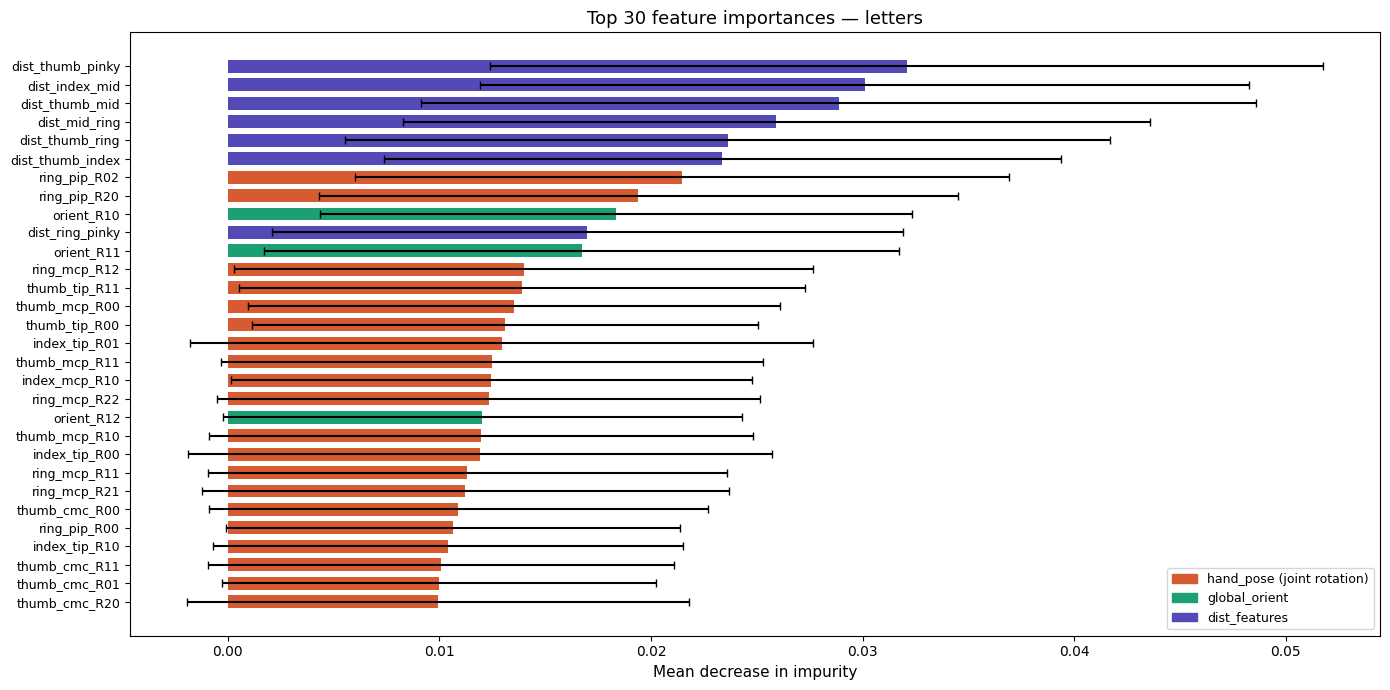


  FEATURE IMPORTANCE — NUMBERS

Rank  Feature                         Importance       Std
----------------------------------------------------------
   1  dist_thumb_pinky                   0.02966   0.04032
   2  orient_R10                         0.02457   0.02973
   3  index_mcp_R00                      0.02065   0.03584
   4  ring_mcp_R21                       0.01900   0.03344
   5  dist_mid_ring                      0.01842   0.02741
   6  dist_index_mid                     0.01751   0.02963
   7  ring_pip_R12                       0.01749   0.02575
   8  index_mcp_R10                      0.01627   0.03217
   9  ring_pip_R02                       0.01591   0.02821
  10  ring_pip_R20                       0.01524   0.02623
  11  dist_thumb_ring                    0.01483   0.02946
  12  index_mcp_R11                      0.01467   0.02943
  13  dist_ring_pinky                    0.01438   0.02526
  14  dist_thumb_index                   0.01417   0.02328
  15  mid_dip_R02      

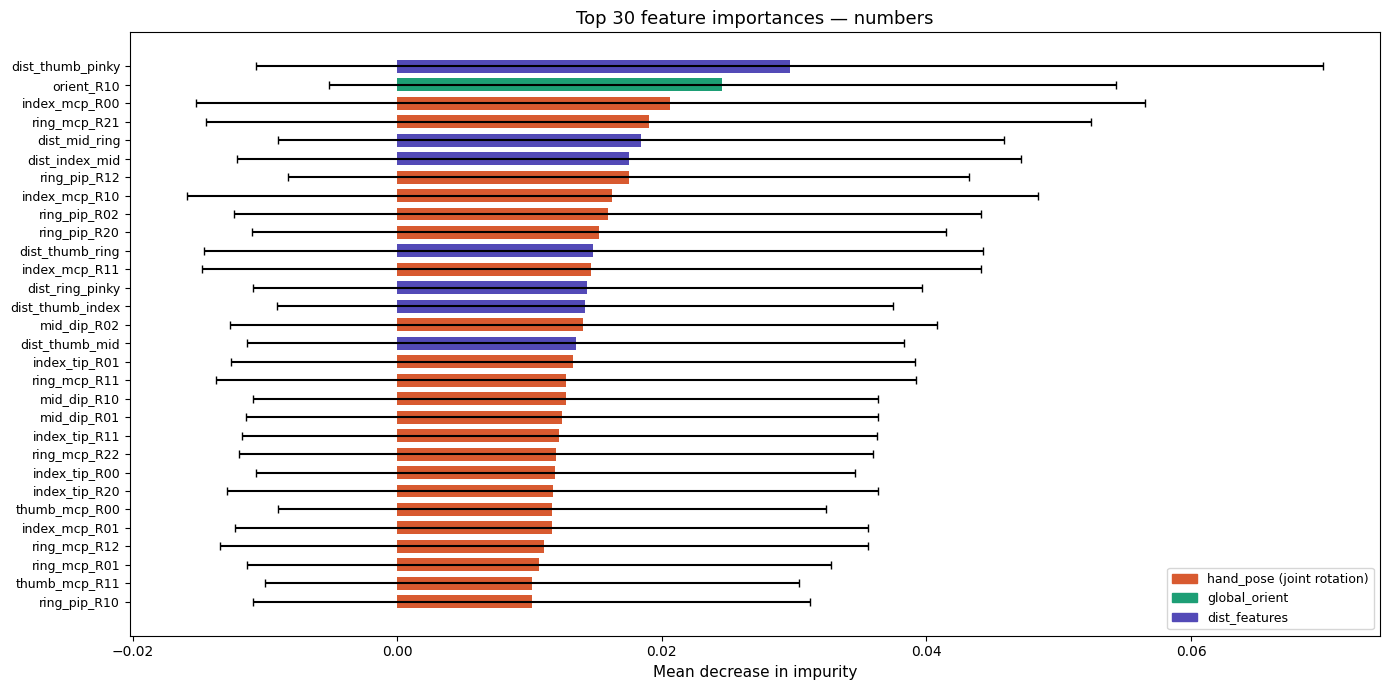

In [5]:
letters_sorted_idx, letters_importances = analyze_feature_importance(
    X_letters, y_letters, FEATURE_NAMES, task="letters"
)

numbers_sorted_idx, numbers_importances = analyze_feature_importance(
    X_numbers, y_numbers, FEATURE_NAMES, task="numbers"
)

In [6]:
def analyze_dimensionality(X, feature_names, task):
    """
    Study how many features/PCA components are actually needed.
    Saves scaler to disk so the training notebook uses the same one.
    """
    print(f"\n{'='*60}")
    print(f"  DIMENSIONALITY STUDY — {task.upper()}")
    print(f"{'='*60}")

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Save scaler — training notebook will load this exact scaler
    scaler_path = os.path.join(DATA_DIR, f"{task}_scaler.pkl")
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved to: {scaler_path}")

    # ── Feature variance plot ──────────────────────────────────────────────
    feat_var   = np.var(X_scaled, axis=0)
    sorted_var = np.argsort(feat_var)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.bar(range(151), feat_var, width=1.0, color="#888780", alpha=0.8)
    ax.axvspan(0,   9,   alpha=0.25, color="#1D9E75", label="global_orient (9)")
    ax.axvspan(9,   144, alpha=0.18, color="#D85A30", label="hand_pose (135)")
    ax.axvspan(144, 151, alpha=0.30, color="#534AB7", label="dist_features (7)")
    ax.set_xlabel("Feature index", fontsize=11)
    ax.set_ylabel("Variance (standardised)", fontsize=11)
    ax.set_title(f"Per-feature variance — {task}", fontsize=12)
    ax.legend(fontsize=9)

    ax2 = axes[1]
    top30 = sorted_var[:30]
    ax2.barh(range(30), feat_var[top30][::-1], color="#D85A30", height=0.7)
    ax2.set_yticks(range(30))
    ax2.set_yticklabels(
        [feature_names[i] for i in top30[::-1]], fontsize=8
    )
    ax2.set_xlabel("Variance", fontsize=11)
    ax2.set_title(f"Top 30 highest-variance features — {task}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"feature_variance_{task}.png", dpi=150)
    plt.show()

    # ── PCA explained variance ─────────────────────────────────────────────
    pca = PCA(n_components=min(151, X_scaled.shape[0]))
    pca.fit(X_scaled)
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    n90 = np.argmax(cumulative >= 0.90) + 1
    n95 = np.argmax(cumulative >= 0.95) + 1
    n99 = np.argmax(cumulative >= 0.99) + 1

    print(f"\nPCA explained variance thresholds:")
    print(f"  90% variance → {n90:3d} components")
    print(f"  95% variance → {n95:3d} components")
    print(f"  99% variance → {n99:3d} components")
    print(f"  Top 10 explain: {cumulative[9]*100:.1f}%")
    print(f"  Top 20 explain: {cumulative[19]*100:.1f}%")
    print(f"  Top 50 explain: {cumulative[49]*100:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(range(1, len(cumulative)+1), cumulative*100,
            color="#534AB7", linewidth=2)
    ax.axhline(90, color="#D85A30", linestyle="--", linewidth=1,
               label=f"90% → {n90} components")
    ax.axhline(95, color="#1D9E75", linestyle="--", linewidth=1,
               label=f"95% → {n95} components")
    ax.axhline(99, color="#888780", linestyle="--", linewidth=1,
               label=f"99% → {n99} components")
    ax.axvline(n90, color="#D85A30", linestyle=":", alpha=0.5)
    ax.axvline(n95, color="#1D9E75", linestyle=":", alpha=0.5)
    ax.set_xlabel("Number of PCA components", fontsize=11)
    ax.set_ylabel("Cumulative explained variance (%)", fontsize=11)
    ax.set_title(f"PCA dimensionality study — {task}", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(1, 151)
    ax.set_ylim(0, 101)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.bar(range(1, 52), pca.explained_variance_ratio_[:51]*100,
            color="#534AB7", alpha=0.8, width=0.8)
    ax2.set_xlabel("PCA component", fontsize=11)
    ax2.set_ylabel("Explained variance (%)", fontsize=11)
    ax2.set_title(f"Scree plot (first 50 components) — {task}", fontsize=12)
    ax2.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"pca_variance_{task}.png", dpi=150)
    plt.show()

    return scaler, X_scaled, n95


  DIMENSIONALITY STUDY — LETTERS
Scaler saved to: /content/letters_scaler.pkl


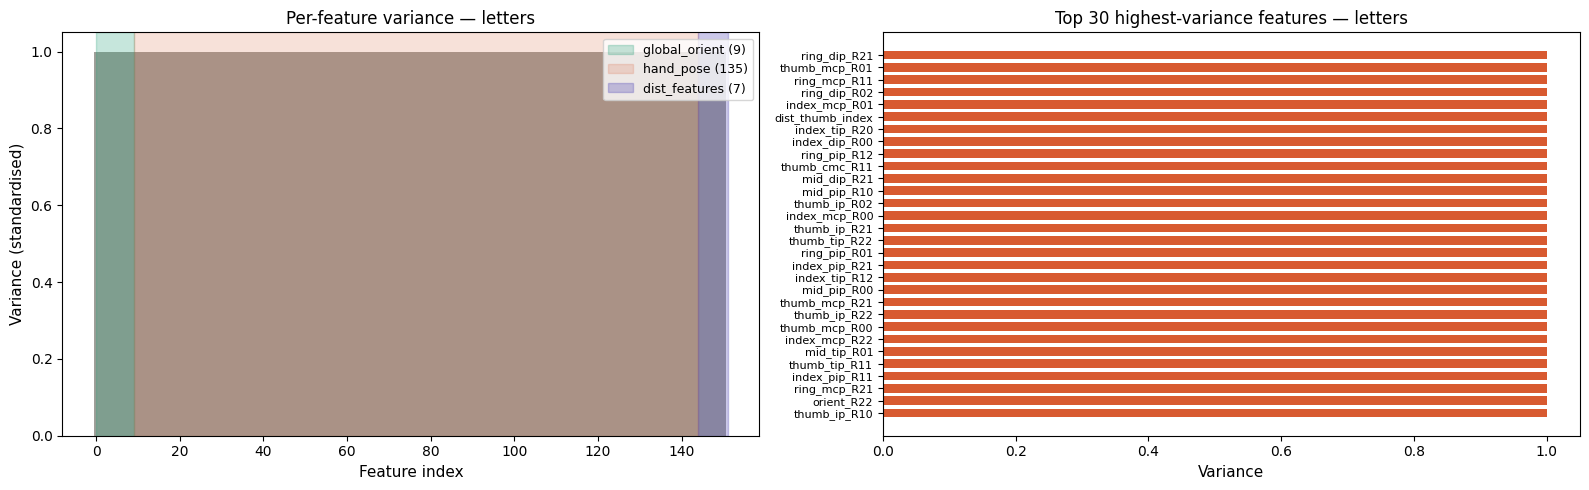


PCA explained variance thresholds:
  90% variance →  27 components
  95% variance →  41 components
  99% variance →  72 components
  Top 10 explain: 71.0%
  Top 20 explain: 85.2%
  Top 50 explain: 97.0%


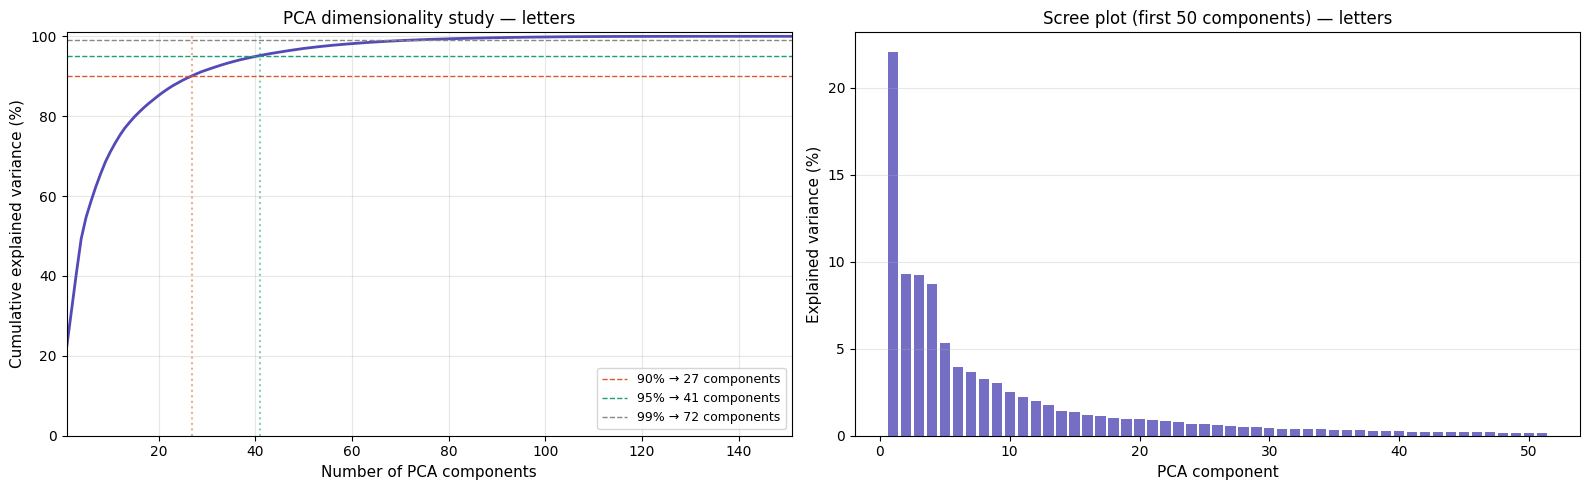


  DIMENSIONALITY STUDY — NUMBERS
Scaler saved to: /content/numbers_scaler.pkl


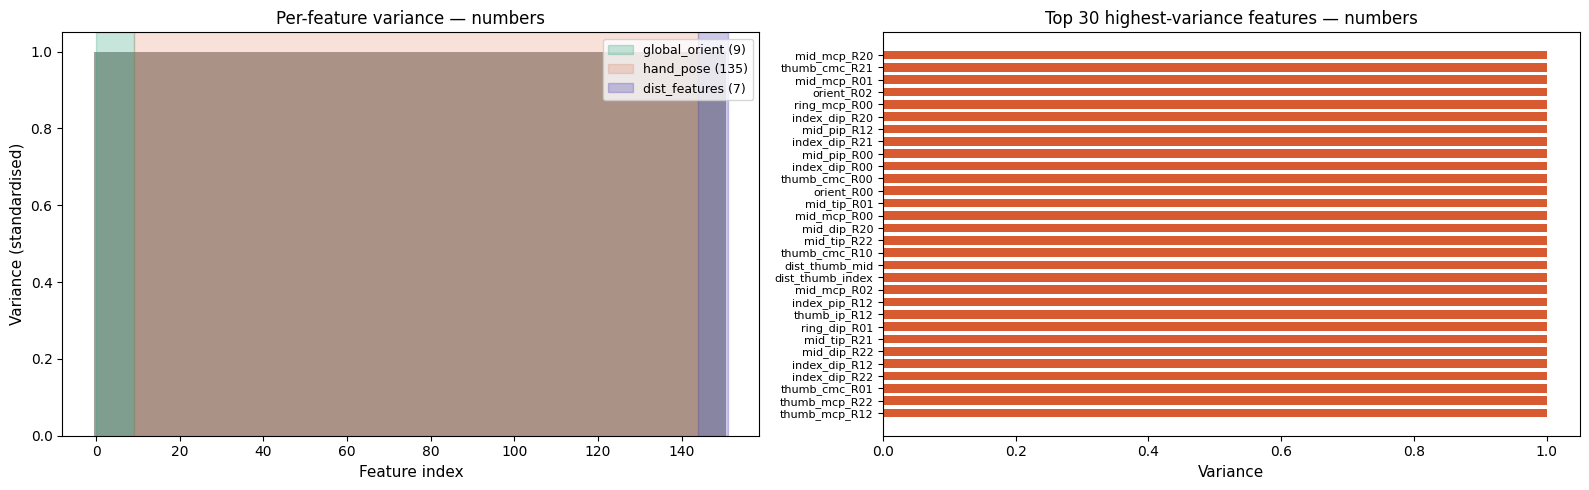


PCA explained variance thresholds:
  90% variance →  28 components
  95% variance →  41 components
  99% variance →  70 components
  Top 10 explain: 71.4%
  Top 20 explain: 84.6%
  Top 50 explain: 97.0%


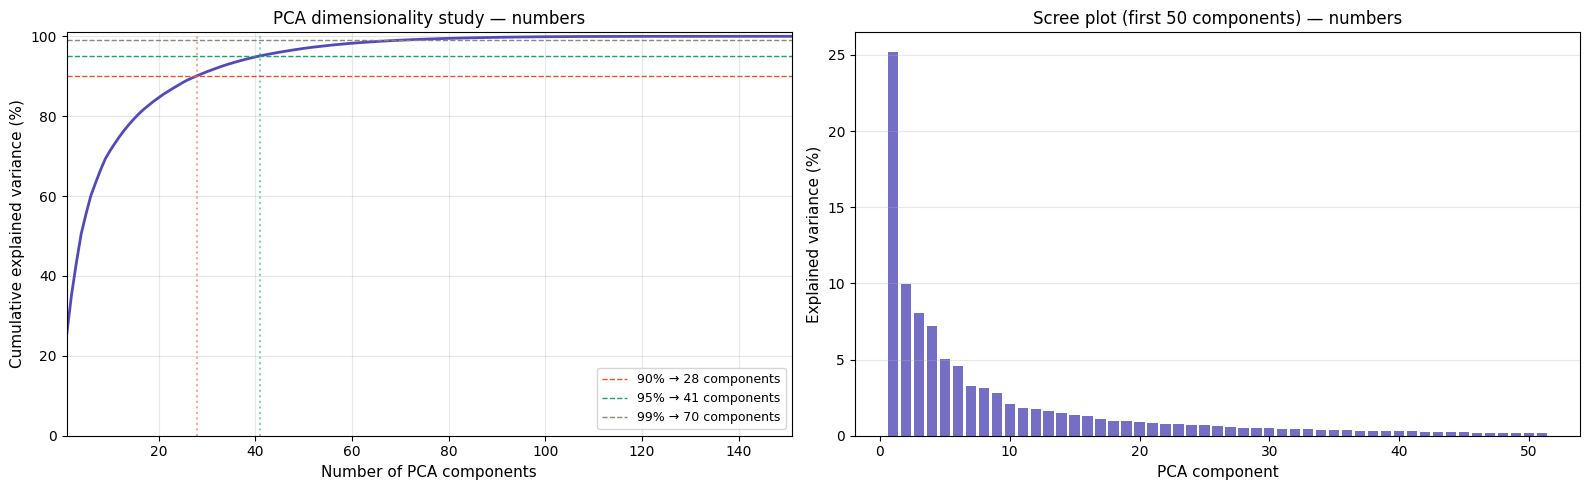

In [7]:
# ── Run Step 2 ─────────────────────────────────────────────────────────────
letters_scaler, X_letters_scaled, letters_n95 = analyze_dimensionality(
    X_letters, FEATURE_NAMES, task="letters"
)

numbers_scaler, X_numbers_scaled, numbers_n95 = analyze_dimensionality(
    X_numbers, FEATURE_NAMES, task="numbers"
)

In [8]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — PCA VISUALISATION
# ══════════════════════════════════════════════════════════════════════════

def visualize_pca(X_scaled, y, encoder, task):
    """
    Class distribution + 2D PCA scatter + 3D PCA scatter.
    """
    print(f"\n{'='*60}")
    print(f"  PCA VISUALISATION — {task.upper()}")
    print(f"{'='*60}")

    class_names = encoder.classes_
    n_classes   = len(class_names)
    cmap        = plt.cm.get_cmap(
        "tab20" if n_classes <= 20 else "gist_ncar", n_classes
    )

    # ── Class distribution ─────────────────────────────────────────────────
    counts  = np.bincount(y)
    fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.5), 5))
    bars    = ax.bar(range(n_classes), counts,
                     color="#534AB7", alpha=0.85, width=0.7)
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Number of samples", fontsize=11)
    ax.set_title(
        f"Class distribution — {task}  "
        f"({n_classes} classes, {len(y)} samples)", fontsize=12
    )
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            str(count), ha="center", va="bottom", fontsize=7
        )
    plt.tight_layout()
    plt.savefig(f"class_distribution_{task}.png", dpi=150)
    plt.show()

    # ── 2D PCA ────────────────────────────────────────────────────────────
    pca2 = PCA(n_components=2, random_state=42)
    X_2d = pca2.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(12, 9))
    for cls_int in range(n_classes):
        mask = y == cls_int
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=class_names[cls_int],
                   color=cmap(cls_int), s=18, alpha=0.65)
    ax.set_xlabel(
        f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11
    )
    ax.set_ylabel(
        f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11
    )
    ax.set_title(
        f"PCA 2D projection — {task}  "
        f"({pca2.explained_variance_ratio_.sum()*100:.1f}% variance)",
        fontsize=12
    )
    ax.legend(
        bbox_to_anchor=(1.01, 1), loc="upper left",
        fontsize=7, ncol=2 if n_classes > 15 else 1
    )
    plt.tight_layout()
    plt.savefig(f"pca_2d_{task}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 3D PCA ────────────────────────────────────────────────────────────
    pca3 = PCA(n_components=3, random_state=42)
    X_3d = pca3.fit_transform(X_scaled)
    var3 = pca3.explained_variance_ratio_

    fig  = plt.figure(figsize=(13, 9))
    ax3d = fig.add_subplot(111, projection="3d")
    for cls_int in range(n_classes):
        mask = y == cls_int
        ax3d.scatter(
            X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
            label=class_names[cls_int],
            color=cmap(cls_int), s=14, alpha=0.6
        )
    ax3d.set_xlabel(f"PC1 ({var3[0]*100:.1f}%)", fontsize=10)
    ax3d.set_ylabel(f"PC2 ({var3[1]*100:.1f}%)", fontsize=10)
    ax3d.set_zlabel(f"PC3 ({var3[2]*100:.1f}%)", fontsize=10)
    ax3d.set_title(
        f"PCA 3D projection — {task}  ({var3.sum()*100:.1f}% variance)",
        fontsize=12
    )
    ax3d.legend(
        bbox_to_anchor=(1.05, 1), loc="upper left",
        fontsize=7, ncol=2 if n_classes > 15 else 1
    )
    plt.tight_layout()
    plt.savefig(f"pca_3d_{task}.png", dpi=150, bbox_inches="tight")
    plt.show()

    v2 = pca2.explained_variance_ratio_.sum() * 100
    v3 = pca3.explained_variance_ratio_.sum() * 100
    print(f"\n2D PCA captures: {v2:.1f}% of variance")
    print(f"3D PCA captures: {v3:.1f}% of variance")


  PCA VISUALISATION — LETTERS


/tmp/ipykernel_28970/1429293175.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap(


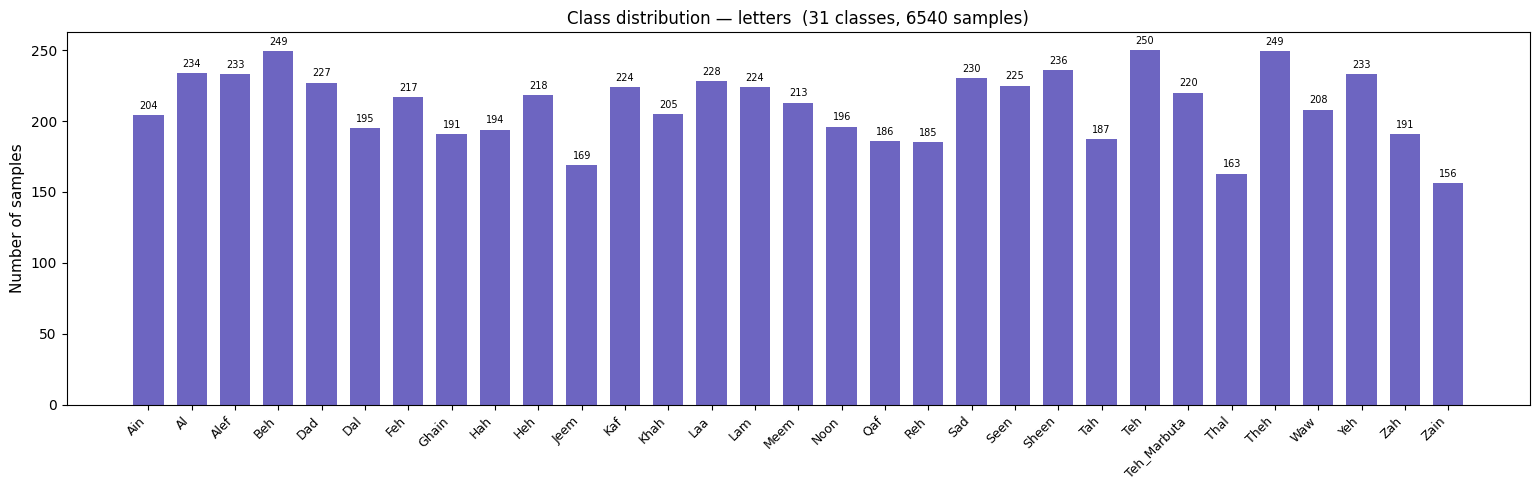

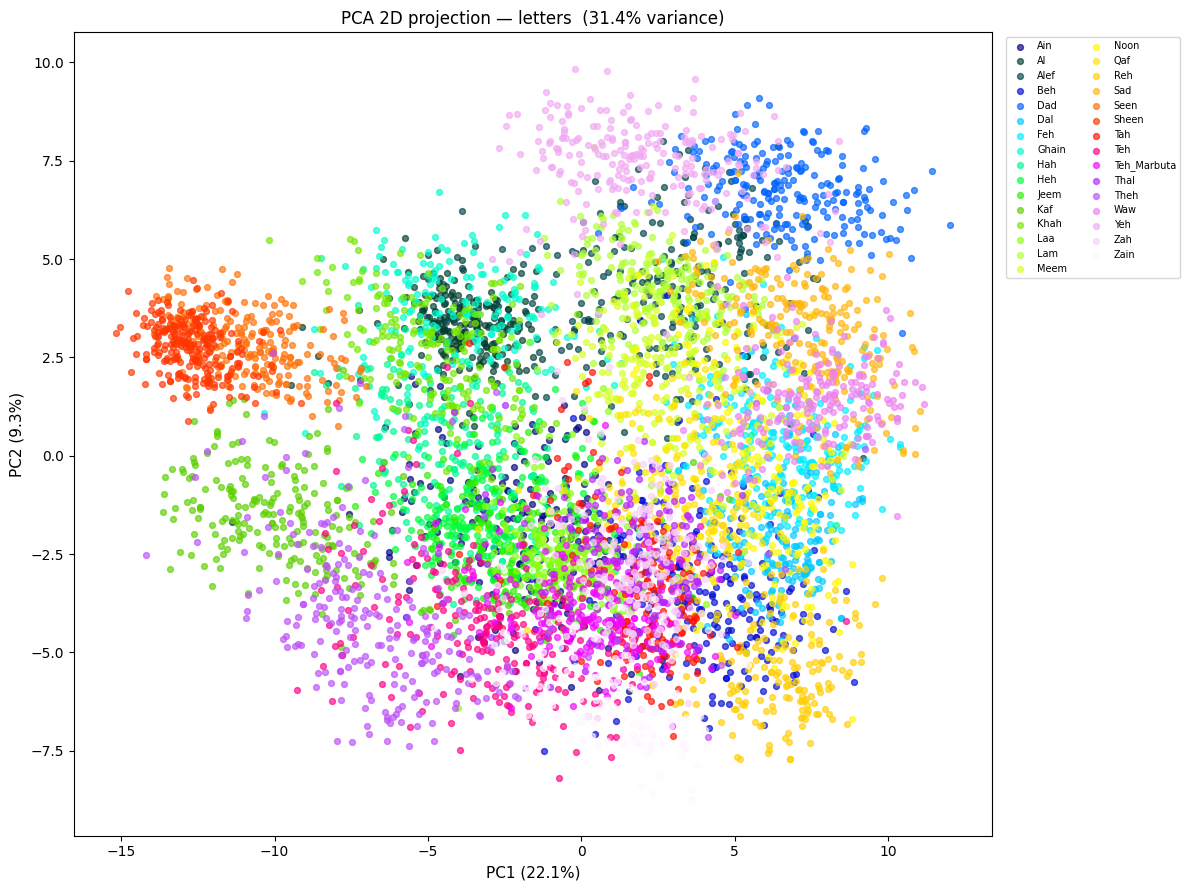

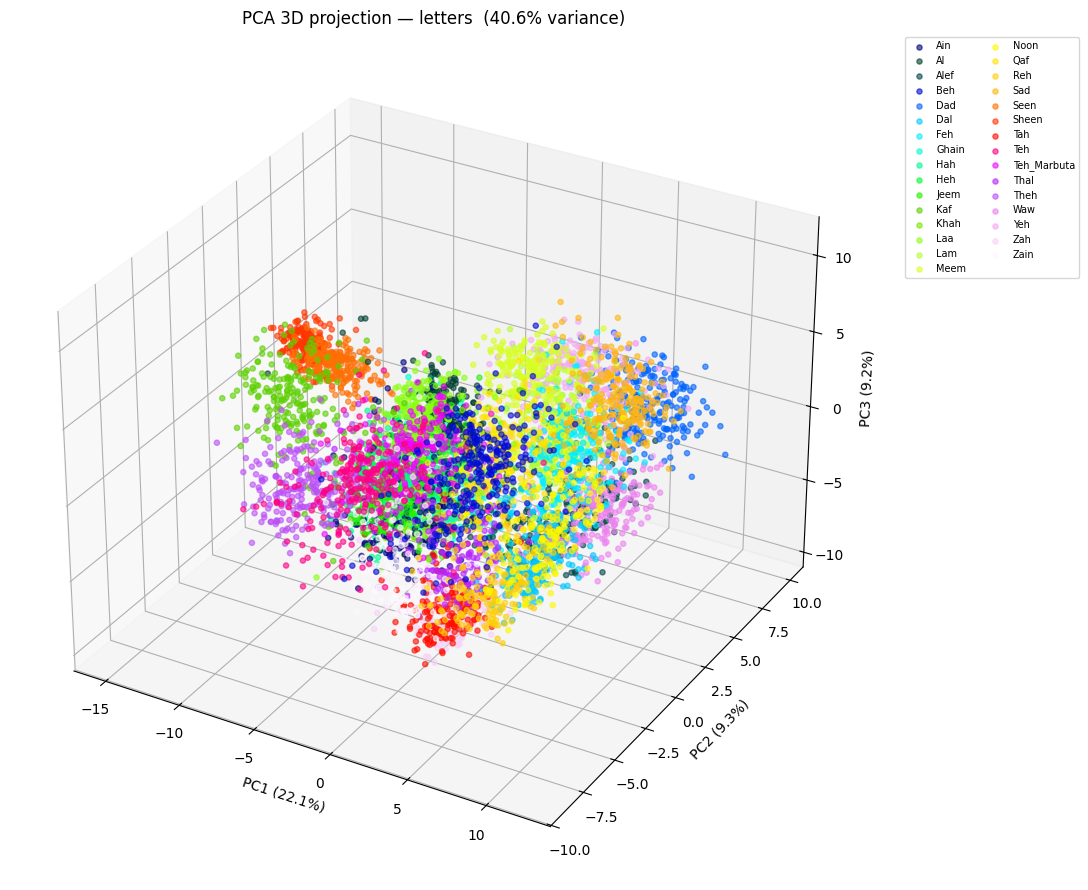


2D PCA captures: 31.4% of variance
3D PCA captures: 40.6% of variance

  PCA VISUALISATION — NUMBERS


/tmp/ipykernel_28970/1429293175.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap(


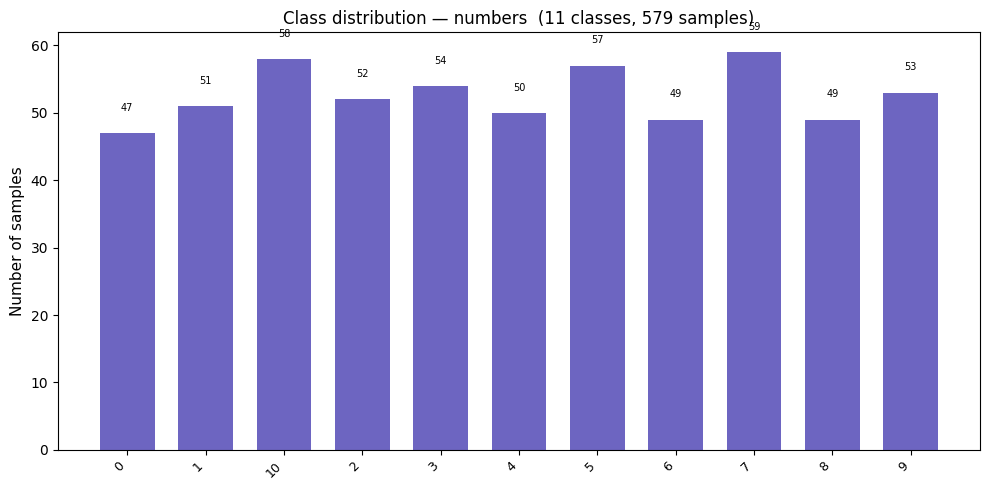

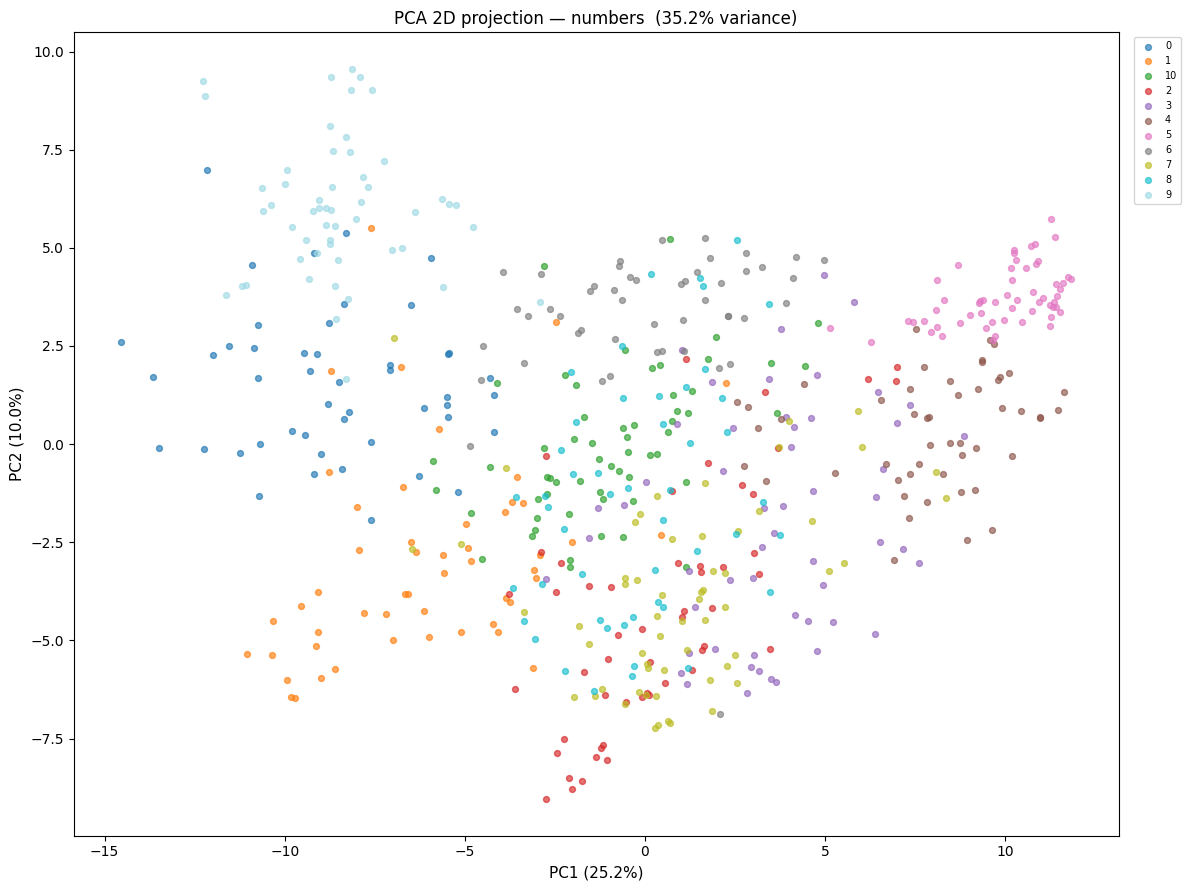

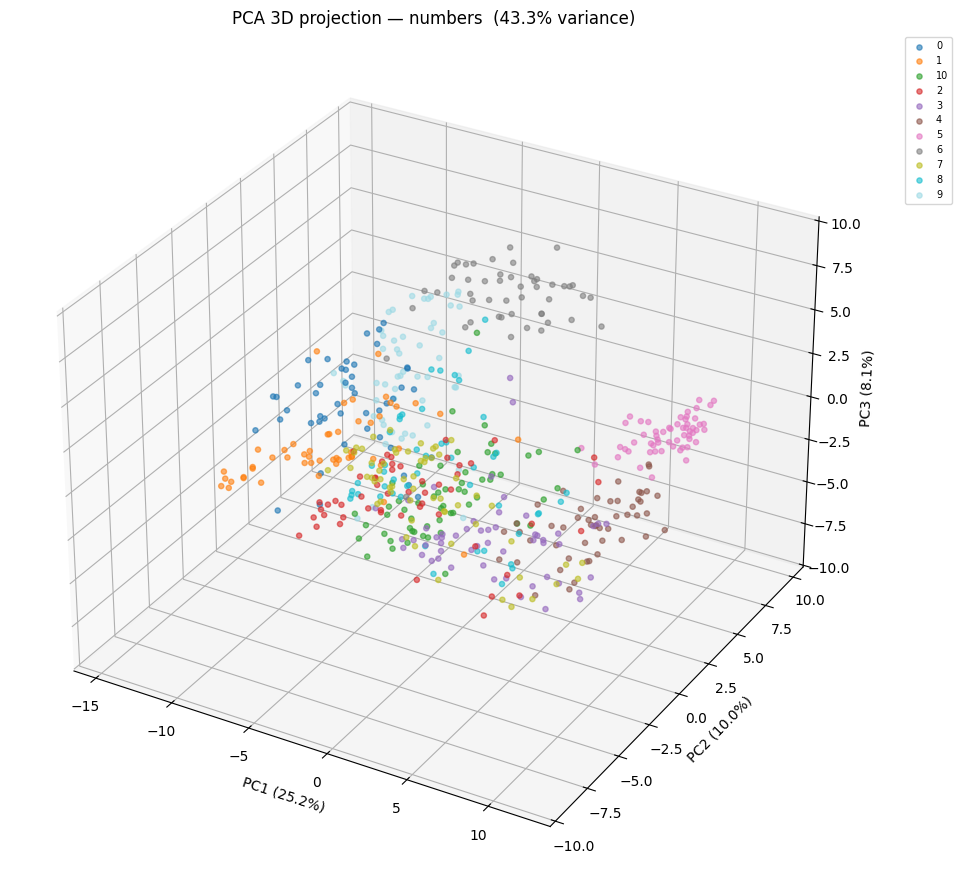


2D PCA captures: 35.2% of variance
3D PCA captures: 43.3% of variance


In [9]:
# ── Run Step 3 ─────────────────────────────────────────────────────────────
visualize_pca(X_letters_scaled, y_letters, letters_encoder, task="letters")
visualize_pca(X_numbers_scaled, y_numbers, numbers_encoder, task="numbers")